In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [4]:
# Number of employees
n = 2000

np.random.seed(42)

employee_id = np.arange(1001, 1001 + n)

age = np.random.randint(21, 60, n)

gender = np.random.choice(["Male", "Female"], n)

education = np.random.choice(
    ["Bachelor", "Master", "PhD"],
    n,
    p=[0.6, 0.3, 0.1]
)

experience = np.random.randint(0, 31, n)

job_role = np.random.choice(
    ["Developer", "Data Analyst", "Manager", "Designer", "HR"],
    n
)

skills = np.random.randint(1, 11, n)

certifications = np.random.randint(0, 11, n)

company = np.random.choice(
    ["Startup", "Medium Scale", "MNC"],
    n
)

work_hours = np.random.randint(35, 61, n)

In [5]:
salary = []

for i in range(n):

    education_bonus = {
        "Bachelor": 0,
        "Master": 80000,
        "PhD": 150000
    }[education[i]]

    company_bonus = {
        "Startup": 20000,
        "Medium Scale": 50000,
        "MNC": 100000
    }[company[i]]

    salary_value = (
        300000
        + experience[i] * 45000
        + skills[i] * 12000
        + certifications[i] * 8000
        + education_bonus
        + company_bonus
        + np.random.randint(-40000, 40000)
    )

    salary.append(salary_value)

In [6]:
df = pd.DataFrame({
    "EmployeeID": employee_id,
    "Age": age,
    "Gender": gender,
    "EducationLevel": education,
    "YearsOfExperience": experience,
    "JobRole": job_role,
    "SkillsScore": skills,
    "Certifications": certifications,
    "CompanyType": company,
    "WorkHoursPerWeek": work_hours,
    "Salary": salary
})

In [7]:
df.head()

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1001,59,Male,Bachelor,21,Data Analyst,2,7,MNC,50,1436319
1,1002,49,Female,Bachelor,23,Data Analyst,6,2,Medium Scale,52,1479728
2,1003,35,Female,Master,6,Data Analyst,10,6,Medium Scale,36,852363
3,1004,28,Male,PhD,29,Data Analyst,1,1,Medium Scale,48,1824300
4,1005,41,Female,Bachelor,26,Data Analyst,4,2,Medium Scale,56,1598808


In [8]:
df.to_csv("employee_salary_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [9]:
print(df.shape)

(2000, 11)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         2000 non-null   int64 
 1   Age                2000 non-null   int32 
 2   Gender             2000 non-null   object
 3   EducationLevel     2000 non-null   object
 4   YearsOfExperience  2000 non-null   int32 
 5   JobRole            2000 non-null   object
 6   SkillsScore        2000 non-null   int32 
 7   Certifications     2000 non-null   int32 
 8   CompanyType        2000 non-null   object
 9   WorkHoursPerWeek   2000 non-null   int32 
 10  Salary             2000 non-null   int32 
dtypes: int32(6), int64(1), object(4)
memory usage: 125.1+ KB


In [11]:
df.head()

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1001,59,Male,Bachelor,21,Data Analyst,2,7,MNC,50,1436319
1,1002,49,Female,Bachelor,23,Data Analyst,6,2,Medium Scale,52,1479728
2,1003,35,Female,Master,6,Data Analyst,10,6,Medium Scale,36,852363
3,1004,28,Male,PhD,29,Data Analyst,1,1,Medium Scale,48,1824300
4,1005,41,Female,Bachelor,26,Data Analyst,4,2,Medium Scale,56,1598808


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         2000 non-null   int64 
 1   Age                2000 non-null   int32 
 2   Gender             2000 non-null   object
 3   EducationLevel     2000 non-null   object
 4   YearsOfExperience  2000 non-null   int32 
 5   JobRole            2000 non-null   object
 6   SkillsScore        2000 non-null   int32 
 7   Certifications     2000 non-null   int32 
 8   CompanyType        2000 non-null   object
 9   WorkHoursPerWeek   2000 non-null   int32 
 10  Salary             2000 non-null   int32 
dtypes: int32(6), int64(1), object(4)
memory usage: 125.1+ KB


In [13]:
df.describe()

,EmployeeID,Age,YearsOfExperience,SkillsScore,Certifications,WorkHoursPerWeek,Salary
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2000.500000,40.358500,15.087500,5.527500,4.953500,47.531500,1.180706e+06
std,577.494589,11.359379,8.948177,2.893688,3.136759,7.574014,4.098108e+05
min,1001.000000,21.000000,0.000000,1.000000,0.000000,35.000000,3.651300e+05
25%,1500.750000,30.000000,7.000000,3.000000,2.000000,41.000000,8.314342e+05
50%,2000.500000,41.000000,15.000000,5.000000,5.000000,48.000000,1.181317e+06
75%,2500.250000,50.000000,23.000000,8.000000,8.000000,54.000000,1.526815e+06
max,3000.000000,59.000000,30.000000,10.000000,10.000000,60.000000,2.008155e+06


In [14]:
df.isnull().sum()

EmployeeID           0
Age                  0
Gender               0
EducationLevel       0
YearsOfExperience    0
JobRole              0
SkillsScore          0
Certifications       0
CompanyType          0
WorkHoursPerWeek     0
Salary               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

In [17]:
print(df["Age"].min())
print(df["Age"].max())

21
59


In [18]:
print(df["YearsOfExperience"].min())
print(df["YearsOfExperience"].max())

0
30


In [19]:
print(df["SkillsScore"].min())
print(df["SkillsScore"].max())

1
10


In [20]:
print(df["Certifications"].min())
print(df["Certifications"].max())

0
10


In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [22]:
df["Gender"] = encoder.fit_transform(df["Gender"])

df["EducationLevel"] = encoder.fit_transform(df["EducationLevel"])

df["JobRole"] = encoder.fit_transform(df["JobRole"])

df["CompanyType"] = encoder.fit_transform(df["CompanyType"])

In [23]:
df.head()

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1001,59,1,0,21,0,2,7,0,50,1436319
1,1002,49,0,0,23,0,6,2,1,52,1479728
2,1003,35,0,1,6,0,10,6,1,36,852363
3,1004,28,1,2,29,0,1,1,1,48,1824300
4,1005,41,0,0,26,0,4,2,1,56,1598808


In [24]:
df.to_csv("employee_salary_cleaned.csv", index=False)

print("Preprocessing completed successfully!")

Preprocessing completed successfully!


In [25]:
## 6. Exploratory Data Analysis (EDA)

In [26]:
df.head(10)

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1001,59,1,0,21,0,2,7,0,50,1436319
1,1002,49,0,0,23,0,6,2,1,52,1479728
2,1003,35,0,1,6,0,10,6,1,36,852363
3,1004,28,1,2,29,0,1,1,1,48,1824300
4,1005,41,0,0,26,0,4,2,1,56,1598808
5,1006,59,0,0,7,1,8,1,1,57,734943
6,1007,39,0,1,18,3,10,4,2,51,1364616
7,1008,43,0,2,19,1,5,6,1,37,1497329
8,1009,31,1,0,15,1,9,10,2,36,1168287
9,1010,31,1,0,21,2,6,9,1,42,1432971


In [27]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 11)


In [28]:
print(df.columns)

Index(['EmployeeID', 'Age', 'Gender', 'EducationLevel', 'YearsOfExperience',
       'JobRole', 'SkillsScore', 'Certifications', 'CompanyType',
       'WorkHoursPerWeek', 'Salary'],
      dtype='object')


In [29]:
df.describe()

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2000.500000,40.358500,0.500000,0.497500,15.087500,1.93800,5.527500,4.953500,0.978000,47.531500,1.180706e+06
std,577.494589,11.359379,0.500125,0.663486,8.948177,1.41886,2.893688,3.136759,0.808606,7.574014,4.098108e+05
min,1001.000000,21.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,35.000000,3.651300e+05
25%,1500.750000,30.000000,0.000000,0.000000,7.000000,1.00000,3.000000,2.000000,0.000000,41.000000,8.314342e+05
50%,2000.500000,41.000000,0.500000,0.000000,15.000000,2.00000,5.000000,5.000000,1.000000,48.000000,1.181317e+06
75%,2500.250000,50.000000,1.000000,1.000000,23.000000,3.00000,8.000000,8.000000,2.000000,54.000000,1.526815e+06
max,3000.000000,59.000000,1.000000,2.000000,30.000000,4.00000,10.000000,10.000000,2.000000,60.000000,2.008155e+06


In [30]:
print("Average Salary:", round(df["Salary"].mean(), 2))

Average Salary: 1180705.91


In [31]:
print("Highest Salary:", df["Salary"].max())

Highest Salary: 2008155


In [32]:
print("Lowest Salary:", df["Salary"].min())

Lowest Salary: 365130


In [33]:
df.corr(numeric_only=True)

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
EmployeeID,1.000000,-0.023887,0.050261,-0.043284,0.000724,0.011583,0.052850,-0.020891,-0.006632,0.017692,0.001361
Age,-0.023887,1.000000,-0.024523,0.009378,0.026705,-0.015039,-0.008039,0.009116,-0.002626,-0.010699,0.027848
Gender,0.050261,-0.024523,1.000000,0.005276,0.015594,0.009870,0.005012,0.012915,-0.017318,0.006801,0.018827
EducationLevel,-0.043284,0.009378,0.005276,1.000000,-0.016604,-0.001228,-0.002309,0.005112,0.024141,-0.011532,0.107381
YearsOfExperience,0.000724,0.026705,0.015594,-0.016604,1.000000,-0.009502,-0.012757,0.005617,-0.006302,0.012275,0.981629
JobRole,0.011583,-0.015039,0.009870,-0.001228,-0.009502,1.000000,-0.012378,0.000813,0.017124,0.023876,-0.011562
SkillsScore,0.052850,-0.008039,0.005012,-0.002309,-0.012757,-0.012378,1.000000,0.013616,-0.005941,-0.003692,0.076159
Certifications,-0.020891,0.009116,0.012915,0.005112,0.005617,0.000813,0.013616,1.000000,0.012219,-0.032565,0.066927
CompanyType,-0.006632,-0.002626,-0.017318,0.024141,-0.006302,0.017124,-0.005941,0.012219,1.000000,0.006893,-0.082745
WorkHoursPerWeek,0.017692,-0.010699,0.006801,-0.011532,0.012275,0.023876,-0.003692,-0.032565,0.006893,1.000000,0.006743


In [34]:
education_map = {
    0: "Bachelor",
    1: "Master",
    2: "PhD"
}

temp = df.copy()
temp["EducationLevel"] = temp["EducationLevel"].map(education_map)

temp.groupby("EducationLevel")["Salary"].mean()

EducationLevel
Bachelor    1.143774e+06
Master      1.229327e+06
PhD         1.255609e+06
Name: Salary, dtype: float64

In [35]:
company_map = {
    0: "MNC",
    1: "Medium Scale",
    2: "Startup"
}

temp["CompanyType"] = temp["CompanyType"].map(company_map)

temp.groupby("CompanyType")["Salary"].mean()

CompanyType
MNC             1.226605e+06
Medium Scale    1.170237e+06
Startup         1.143074e+06
Name: Salary, dtype: float64

In [36]:
job_map = {
    0: "Data Analyst",
    1: "Designer",
    2: "Developer",
    3: "HR",
    4: "Manager"
}

temp["JobRole"] = temp["JobRole"].map(job_map)

temp.groupby("JobRole")["Salary"].mean()

JobRole
Data Analyst    1.168300e+06
Designer        1.195230e+06
Developer       1.200412e+06
HR              1.185182e+06
Manager         1.154000e+06
Name: Salary, dtype: float64

In [38]:
## 7. Data Visualization

In [39]:
plt.style.use("ggplot")

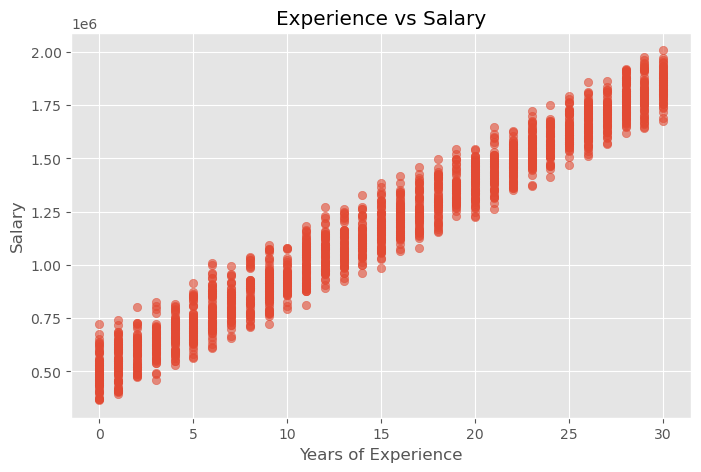

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(df["YearsOfExperience"], df["Salary"], alpha=0.6)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [41]:
job_map = {
    0: "Data Analyst",
    1: "Designer",
    2: "Developer",
    3: "HR",
    4: "Manager"
}

temp = df.copy()
temp["JobRole"] = temp["JobRole"].map(job_map)

average_salary = temp.groupby("JobRole")["Salary"].mean().sort_values()

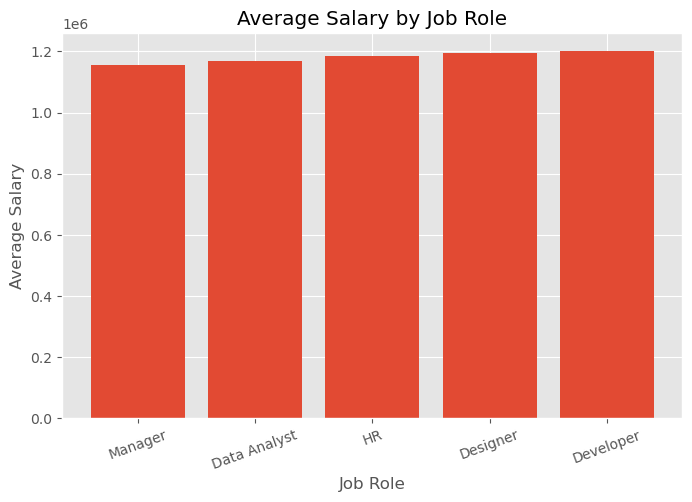

In [42]:
plt.figure(figsize=(8,5))

plt.bar(average_salary.index, average_salary.values)

plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")

plt.xticks(rotation=20)

plt.show()

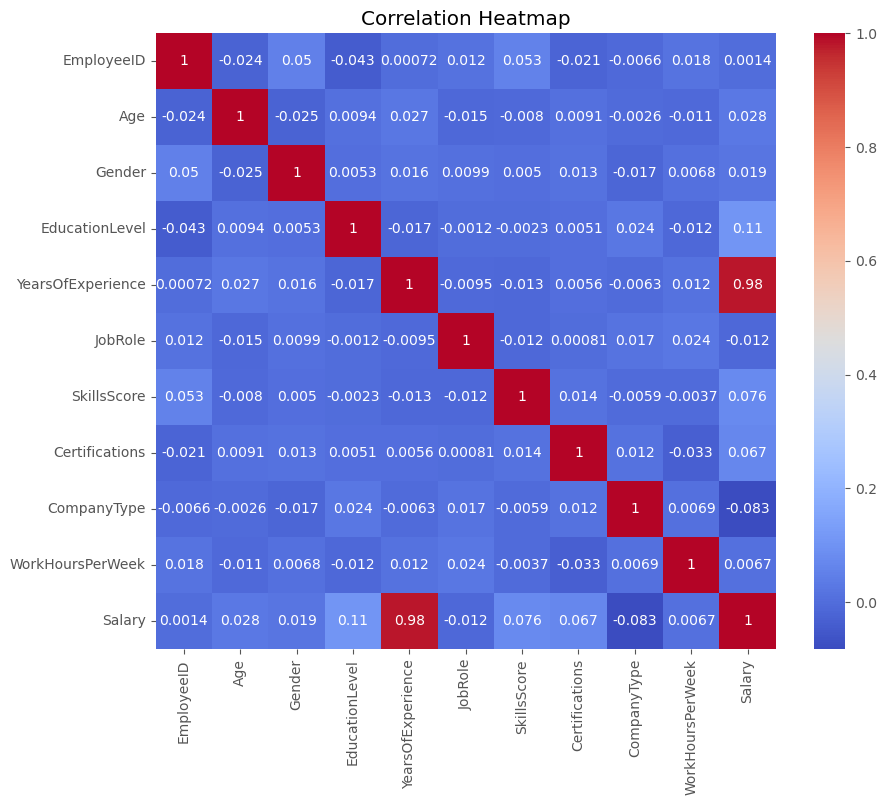

In [43]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [44]:
education_map = {
    0: "Bachelor",
    1: "Master",
    2: "PhD"
}

temp = df.copy()

temp["EducationLevel"] = temp["EducationLevel"].map(education_map)

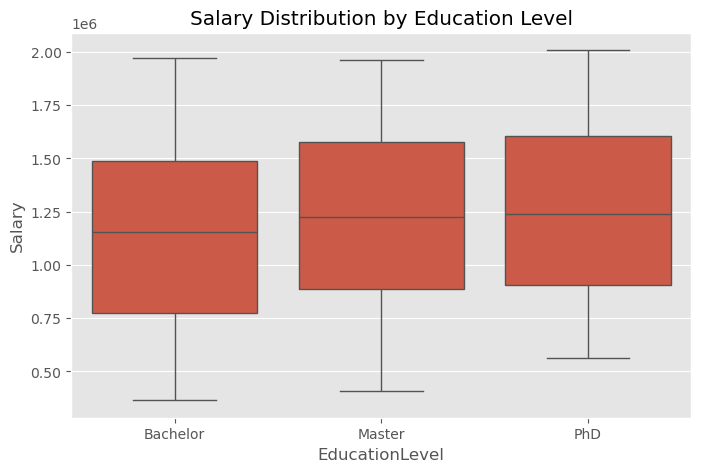

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=temp,
    x="EducationLevel",
    y="Salary"
)

plt.title("Salary Distribution by Education Level")

plt.show()

In [46]:
plt.savefig("experience_vs_salary.png")

<Figure size 640x480 with 0 Axes>

In [49]:
## 8. Machine Learning Model

In [50]:
X = df.drop(["EmployeeID", "Salary"], axis=1)

y = df["Salary"]

In [51]:
print(X.head())
print(y.head())

   Age  Gender  EducationLevel  YearsOfExperience  JobRole  SkillsScore  \
0   59       1               0                 21        0            2   
1   49       0               0                 23        0            6   
2   35       0               1                  6        0           10   
3   28       1               2                 29        0            1   
4   41       0               0                 26        0            4   

   Certifications  CompanyType  WorkHoursPerWeek  
0               7            0                50  
1               2            1                52  
2               6            1                36  
3               1            1                48  
4               2            1                56  
0    1436319
1    1479728
2     852363
3    1824300
4    1598808
Name: Salary, dtype: int32


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (1600, 9)
Testing Data : (400, 9)


In [54]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [55]:
lr_pred = lr.predict(X_test)

In [56]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
-------------------------
MAE : 20498.310640346055
RMSE: 23757.020579793567
R2 Score: 0.9965299562994366


In [57]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [58]:
dt_pred = dt.predict(X_test)

In [59]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("---------------------")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results
---------------------
MAE : 44399.265
RMSE: 56130.81172284078
R2 Score: 0.9806289286035801


In [60]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [61]:
rf_pred = rf.predict(X_test)

In [62]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
---------------------
MAE : 29399.979525000002
RMSE: 35542.24591452547
R2 Score: 0.9922332248716346


In [63]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20498.310640,23757.020580,0.996530
1,Decision Tree,44399.265000,56130.811723,0.980629
2,Random Forest,29399.979525,35542.245915,0.992233


In [64]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model")
print(best_model)

Best Model
Model       Linear Regression
MAE               20498.31064
RMSE              23757.02058
R2 Score              0.99653
Name: 0, dtype: object


In [65]:
joblib.dump(rf, "salary_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [66]:
loaded_model = joblib.load("salary_prediction_model.pkl")

print(loaded_model)

RandomForestRegressor(random_state=42)


In [68]:
## 9. Interactive Salary Prediction System

In [69]:
import joblib

model = joblib.load("salary_prediction_model.pkl")

In [70]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
gender_encoder.fit(["Male", "Female"])
print("Gender:", dict(zip(gender_encoder.classes_, gender_encoder.transform(gender_encoder.classes_))))

education_encoder = LabelEncoder()
education_encoder.fit(["Bachelor", "Master", "PhD"])
print("Education:", dict(zip(education_encoder.classes_, education_encoder.transform(education_encoder.classes_))))

job_encoder = LabelEncoder()
job_encoder.fit(["Developer", "Data Analyst", "Manager", "Designer", "HR"])
print("Job Role:", dict(zip(job_encoder.classes_, job_encoder.transform(job_encoder.classes_))))

company_encoder = LabelEncoder()
company_encoder.fit(["Startup", "Medium Scale", "MNC"])
print("Company Type:", dict(zip(company_encoder.classes_, company_encoder.transform(company_encoder.classes_))))

Gender: {np.str_('Female'): np.int64(0), np.str_('Male'): np.int64(1)}
Education: {np.str_('Bachelor'): np.int64(0), np.str_('Master'): np.int64(1), np.str_('PhD'): np.int64(2)}
Job Role: {np.str_('Data Analyst'): np.int64(0), np.str_('Designer'): np.int64(1), np.str_('Developer'): np.int64(2), np.str_('HR'): np.int64(3), np.str_('Manager'): np.int64(4)}
Company Type: {np.str_('MNC'): np.int64(0), np.str_('Medium Scale'): np.int64(1), np.str_('Startup'): np.int64(2)}


In [72]:
# Load model
model = joblib.load("salary_prediction_model.pkl")

print("===== Employee Salary Prediction =====")

# Numerical inputs
age = int(input("Enter Age: "))
experience = int(input("Enter Years of Experience: "))
skills = int(input("Enter Skills Score (1-10): "))
certifications = int(input("Enter Number of Certifications: "))
work_hours = int(input("Enter Work Hours Per Week: "))

# Encoded categorical inputs
print("\nGender: Male=1, Female=0")
gender = int(input("Enter Gender: "))

print("\nEducation: Bachelor=0, Master=1, PhD=2")
education = int(input("Enter Education Level: "))

print("\nJob Role:")
print("Data Analyst=0")
print("Designer=1")
print("Developer=2")
print("HR=3")
print("Manager=4")
job = int(input("Enter Job Role: "))

print("\nCompany Type:")
print("MNC=0")
print("Medium Scale=1")
print("Startup=2")
company = int(input("Enter Company Type: "))

# Create input list
user_data = pd.DataFrame({
    "Age": [age],
    "Gender": [gender],
    "EducationLevel": [education],
    "YearsOfExperience": [experience],
    "JobRole": [job],
    "SkillsScore": [skills],
    "Certifications": [certifications],
    "CompanyType": [company],
    "WorkHoursPerWeek": [work_hours]
})

predicted_salary = model.predict(user_data)

print("\nPredicted Employee Salary")
print(f"₹ {predicted_salary[0]:,.2f}")

===== Employee Salary Prediction =====


Enter Age:  5
Enter Years of Experience:  5
Enter Skills Score (1-10):  1
Enter Number of Certifications:  4
Enter Work Hours Per Week:  45



Gender: Male=1, Female=0


Enter Gender:  1



Education: Bachelor=0, Master=1, PhD=2


...


Job Role:
Data Analyst=0
Designer=1
Developer=2
HR=3
Manager=4


Enter Job Role:  1



Company Type:
MNC=0
Medium Scale=1
Startup=2


Enter Company Type:  0



Predicted Employee Salary
₹ 733,119.05


In [73]:
import os

print(os.getcwd())

C:\Users\rpooj


In [74]:
import glob

for file in glob.glob("*"):
    print(file)

-1.14-windows.xml
anaconda3
anaconda_projects
AndroidStudioProjects
AppData
Application Data
Cisco Packet Tracer 8.2.2
Contacts
Cookies
decision_tree_model.joblib
department_codes.csv
department_mean_salary_comparison.csv
Documents
Downloads
dt_digits.joblib
eclipse
eclipse-workspace
employee_data.csv
employee_salary_cleaned.csv
employee_salary_dataset.csv
Employee_Salary_Prediction.ipynb
endsemai.ipynb
exp-10.ipynb
exp-11.ipynb
exp-7.ipynb
exp-8.ipynb
exp-9.ipynb
exp3.ipynb
exp4.ipynb
exp5.ipynb
Exp6.ipynb
experience_vs_salary.png
Favorites
frontend
iris.csv
jobrole_salary.png
Links
Local Settings
Music
My Documents
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{489e647a-094e-11f1-96d1-fc59db47b912}.TM.blf
NTUSER.DAT{489e647a-094e-11f1-96d1-fc59db47b912}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{489e647a-094e-11f1-96d1-fc59db47b912}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
PrintHood
Project-12
PyCharmMiscProject
Recent
salary_predicti